In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("Gaming_Academic_Performance.csv")

In [5]:
print(df.head())

   student_id  age  gender  gaming_hours  study_hours  sleep_hours  \
0           1   22    Male          7.23         8.78         6.96   
1           2   19    Male          0.07         8.72         7.63   
2           3   23  Female          1.73         9.56         4.40   
3           4   20  Female          6.62         1.68         7.83   
4           5   22  Female          5.36         5.83         5.55   

   attendance gaming_genre  social_activity  device_usage  reaction_time_ms  \
0       91.44          FPS             3.25          9.36            235.84   
1       63.63       Casual             1.02          3.21            328.71   
2       83.26       Casual             3.46          5.56            313.61   
3       75.04          RPG             1.46         11.78            241.84   
4       65.57          FPS             1.01          8.23            249.31   

   addiction_score stress_level     grades  
0            14.69          Low  86.459555  
1             

In [6]:
print(df.describe())

       student_id          age  gaming_hours  study_hours  sleep_hours  \
count  8000.00000  8000.000000   8000.000000  8000.000000  8000.000000   
mean   4000.50000    19.983625      4.085773     5.460581     6.493453   
std    2309.54541     2.587072      2.308801     2.575787     1.442656   
min       1.00000    16.000000      0.000000     1.000000     4.000000   
25%    2000.75000    18.000000      2.130000     3.240000     5.240000   
50%    4000.50000    20.000000      4.130000     5.460000     6.505000   
75%    6000.25000    22.000000      6.060000     7.660000     7.730000   
max    8000.00000    24.000000      8.000000    10.000000     9.000000   

        attendance  social_activity  device_usage  reaction_time_ms  \
count  8000.000000      8000.000000   8000.000000       8000.000000   
mean     79.886525         2.507790      7.586315        271.105839   
std      11.580419         1.441128      2.710035         29.440675   
min      60.000000         0.000000      1.100000

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [8]:
###Run a heatmap to find correlation between all these variables

In [9]:
df.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
###Heatmap to display strong correlation

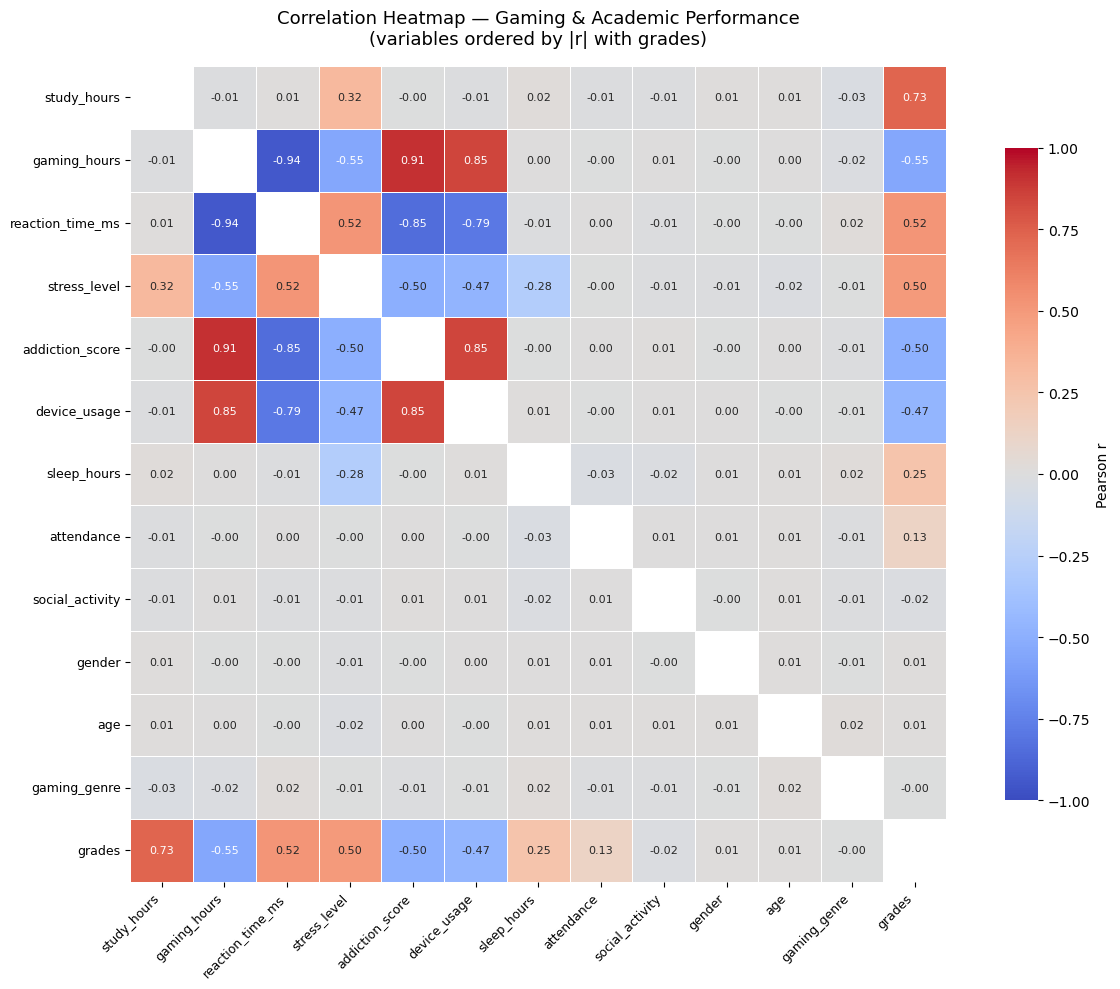

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Gaming_Academic_Performance.csv')

# Encode categoricals
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Other': 2})
df['gaming_genre'] = df['gaming_genre'].map({'Casual': 0, 'RPG': 1, 'FPS': 2})
df['stress_level'] = df['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df = df.drop(columns=['student_id'])

# Compute correlation matrix ordered by abs correlation with grades
corr = df.corr()
grade_order = corr['grades'].drop('grades').abs().sort_values(ascending=False).index.tolist()
ordered_cols = grade_order + ['grades']
corr_ordered = corr.loc[ordered_cols, ordered_cols]

# Plot
plt.figure(figsize=(13, 10))
mask = np.eye(len(corr_ordered), dtype=bool)  # mask diagonal

sns.heatmap(
    corr_ordered,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    mask=mask,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

plt.title('Correlation Heatmap — Gaming & Academic Performance\n(variables ordered by |r| with grades)',
          fontsize=13, pad=16)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df_filtered = df.drop(columns = ['gaming_genre', 'reaction_time_ms'])

In [21]:
df_filtered.head()

,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,addiction_score,stress_level,grades,gender_1,gender_2
0,22,7.23,8.78,6.96,91.44,3.25,9.36,14.69,0,86.459555,False,False
1,19,0.07,8.72,7.63,63.63,1.02,3.21,2.47,1,98.230000,False,False
2,23,1.73,9.56,4.40,83.26,3.46,5.56,4.73,2,90.560000,True,False
3,20,6.62,1.68,7.83,75.04,1.46,11.78,14.54,0,32.670000,True,False
4,22,5.36,5.83,5.55,65.57,1.01,8.23,12.48,0,58.710000,True,False


In [20]:
df_filtered = pd.get_dummies(df_filtered, columns=['gender'], drop_first=True)

In [ ]:
###Running linear regression model

In [24]:
X = df_filtered.drop(columns=['grades'])
y = df_filtered['grades']

In [27]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3473)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred    = model.predict(X_test)
r2_test   = r2_score(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))


print(f"\nTest R²  : {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")



Test R²  : 0.9091
Test RMSE: 6.6812


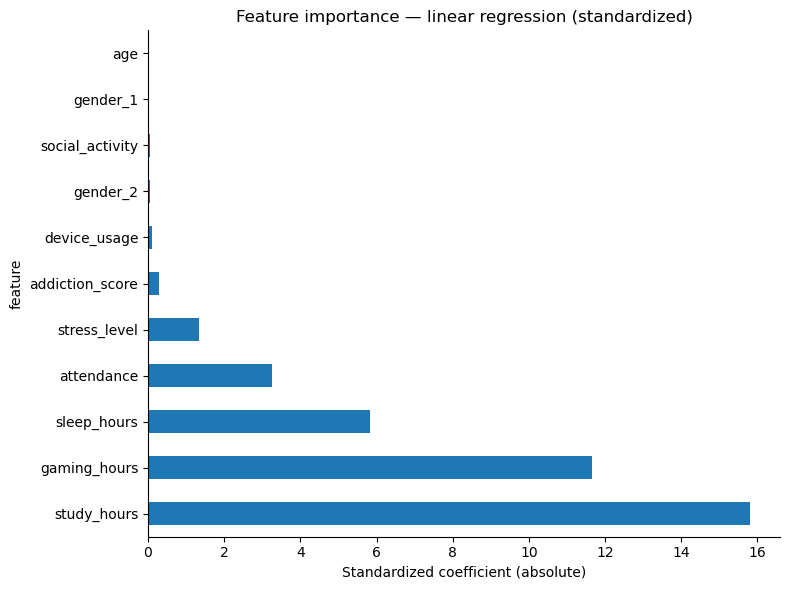

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LinearRegression()
lr.fit(X_scaled, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(lr.coef_)  # absolute value = magnitude of impact
}).sort_values('importance', ascending=False)

importance_df.plot.barh(x='feature', y='importance', legend=False, figsize=(8, 6))
plt.xlabel('Standardized coefficient (absolute)')
plt.title('Feature importance — linear regression (standardized)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [29]:
df.iloc[4391]

age                     22
gaming_hours          3.08
study_hours           3.96
sleep_hours           5.35
attendance           72.33
gaming_genre             0
social_activity        4.6
device_usage          4.25
reaction_time_ms    286.31
addiction_score        5.9
stress_level             1
grades               56.56
gender_1             False
gender_2             False
Name: 4391, dtype: object

In [30]:
df.iloc[4392]

age                     17
gaming_hours          2.86
study_hours           1.11
sleep_hours           4.71
attendance           90.09
gaming_genre             1
social_activity       0.68
device_usage          3.88
reaction_time_ms    298.27
addiction_score       6.95
stress_level             1
grades               42.33
gender_1              True
gender_2             False
Name: 4392, dtype: object

In [31]:
df.iloc[4390]

age                         24
gaming_hours              5.05
study_hours               9.02
sleep_hours               8.98
attendance               81.35
gaming_genre                 2
social_activity           0.24
device_usage              6.48
reaction_time_ms        282.12
addiction_score          10.35
stress_level                 0
grades              118.632936
gender_1                  True
gender_2                 False
Name: 4390, dtype: object

In [42]:
df2 = df[df['gaming_hours'] >= 1]

In [43]:
df2.describe()

,age,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
count,7026.000000,7026.000000,7026.000000,7026.000000,7026.000000,7026.000000,7026.000000,7026.000000,7026.000000,7026.000000,7026.000000,7026.000000
mean,19.983490,4.584093,5.452246,6.495618,79.821137,1.093510,2.499638,8.074341,265.139555,10.896410,0.734557,64.036473
std,2.588067,2.004669,2.579681,1.439196,11.541328,0.832059,1.441463,2.472644,26.044716,4.495997,0.667064,22.359118
min,16.000000,1.000000,1.000000,4.000000,60.000000,0.000000,0.000000,2.050000,183.260000,-1.390000,0.000000,0.000000
25%,18.000000,2.870000,3.210000,5.240000,69.790000,0.000000,1.272500,6.260000,244.205000,7.450000,0.000000,47.665000
50%,20.000000,4.630000,5.440000,6.500000,79.600000,1.000000,2.490000,8.100000,264.665000,10.930000,1.000000,64.370000
75%,22.000000,6.287500,7.660000,7.730000,89.970000,2.000000,3.750000,9.860000,286.010000,14.397500,1.000000,81.557334
max,24.000000,8.000000,10.000000,9.000000,100.000000,2.000000,5.000000,13.950000,337.800000,23.160000,2.000000,118.632936
